<a href="https://colab.research.google.com/github/Brunno1012/Analise-Vendas/blob/main/Vendas_Mercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

In [ ]:
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
try:
  df = pd.read_csv("supermarket_sales - Sheet1.csv")
  print("Os dados foram carregados com sucesso!")
except:
  print("Erro ao carregar os dados! Baixe o arquivo primeiro")
  exit()

Os dados foram carregados com sucesso!


In [ ]:
print(f"\n O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas")


 O dataset possui 1000 linhas e 17 colunas


In [ ]:
#Primeira analise do dataset
print(df.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

In [ ]:
#Analise das informaçoes da coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
#Transformando a coluna date pro formato date
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
#Adicionando as colunas mes, dia, hora e total

df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Total'] = df['Quantity'] * df['Unit price']

<ipython-input-8-6f84fd76804e>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


In [ ]:
#Verificando a quantidade de valores nulos por coluna
print(df.isna().sum())

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Day                        0
Hour                       0
dtype: int64


<ipython-input-10-ca02ff735f5e>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='City', y='Total', estimator=sum, ci=None)


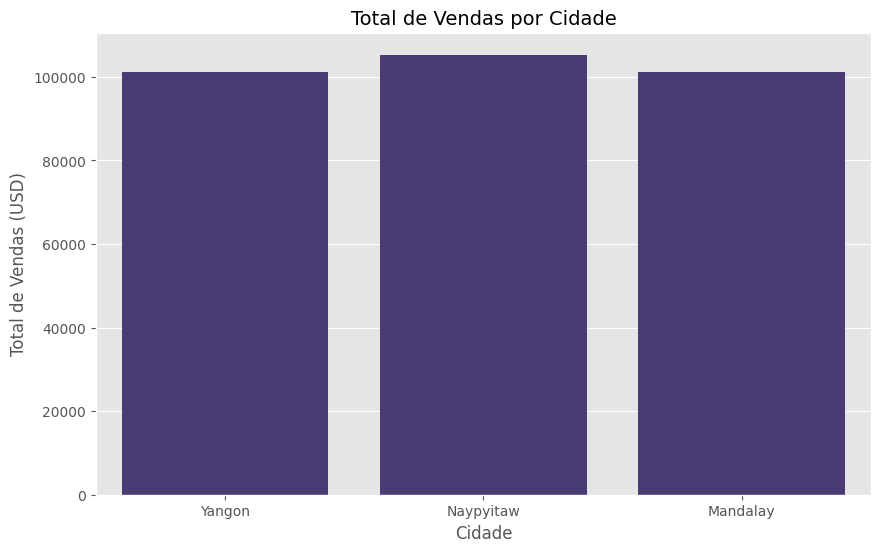

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='City', y='Total', estimator=sum, ci=None)
plt.title('Total de Vendas por Cidade', fontsize=14)
plt.xlabel('Cidade')
plt.ylabel('Total de Vendas (USD)')
plt.show()

#Total de vendas por cidade.

<ipython-input-11-9e72b9c7f60d>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Product line', y='Total', estimator=sum, ci=None)


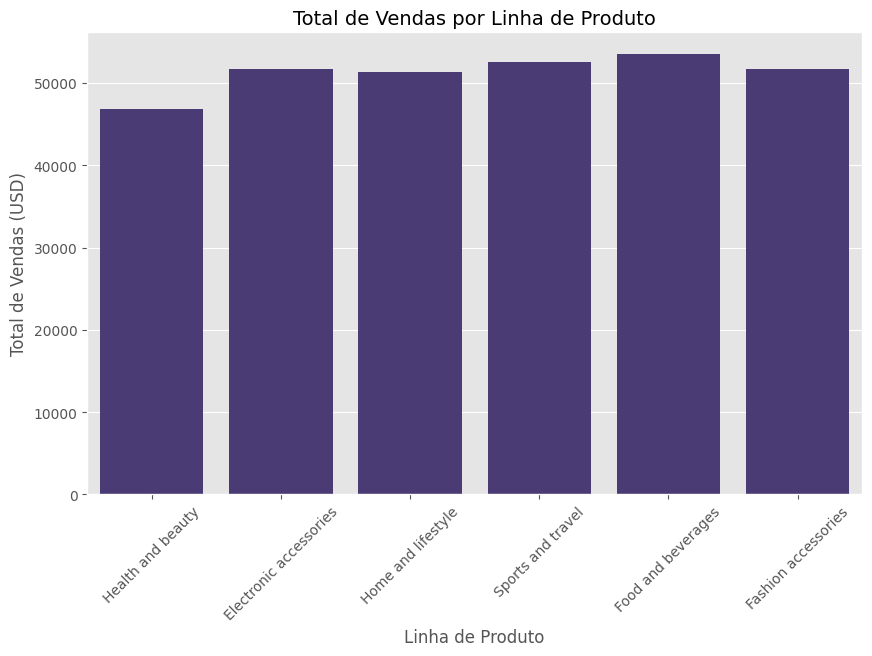

In [ ]:
#Vendas por linha de produto

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Product line', y='Total', estimator=sum, ci=None)
plt.title('Total de Vendas por Linha de Produto', fontsize=14)
plt.xlabel('Linha de Produto')
plt.ylabel('Total de Vendas (USD)')
plt.xticks(rotation=45)
plt.show()

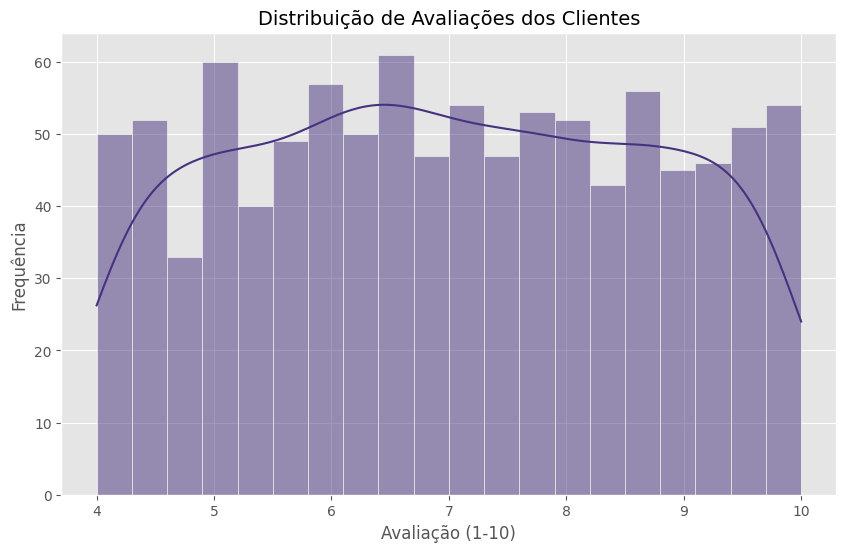

In [ ]:
#Distribuição das avaliaçoes
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribuição de Avaliações dos Clientes', fontsize=14)
plt.xlabel('Avaliação (1-10)')
plt.ylabel('Frequência')
plt.show()

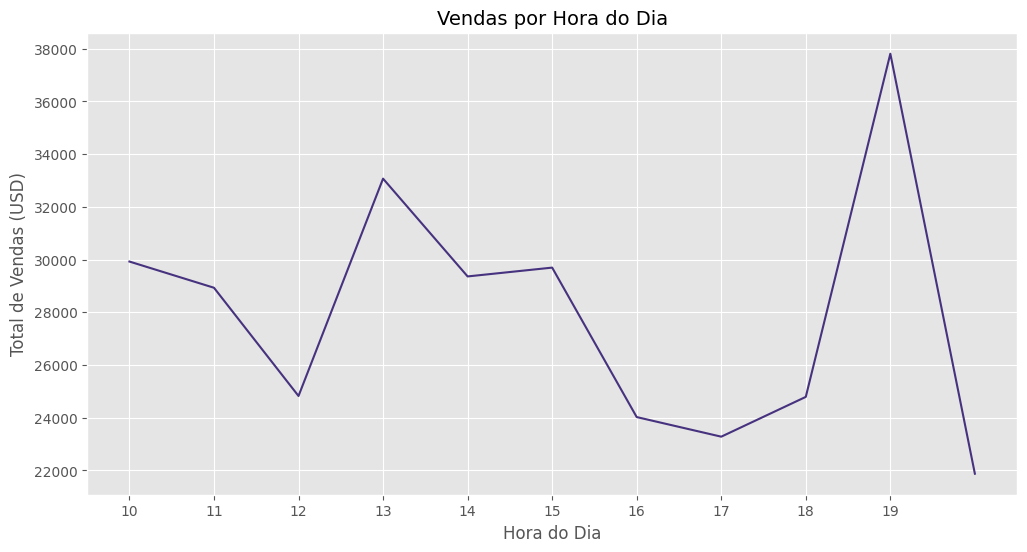

In [ ]:
#Vendas ao longo do dia
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.groupby('Hour')['Total'].sum().reset_index(), x='Hour', y='Total')
plt.title('Vendas por Hora do Dia', fontsize=14)
plt.xlabel('Hora do Dia')
plt.ylabel('Total de Vendas (USD)')
plt.xticks(range(10, 20))
plt.show()

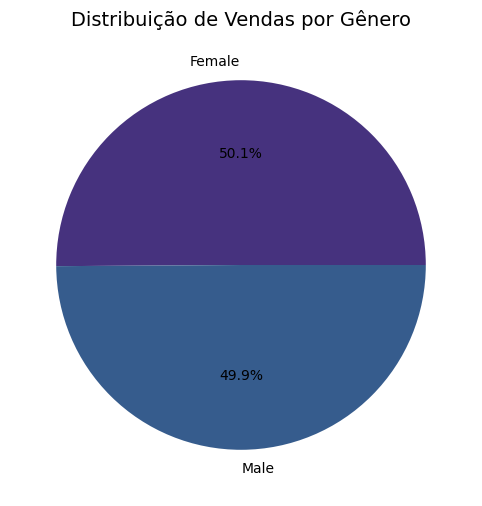

In [ ]:
plt.figure(figsize=(8, 6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribuição de Vendas por Gênero', fontsize=14)
plt.ylabel('')
plt.show()

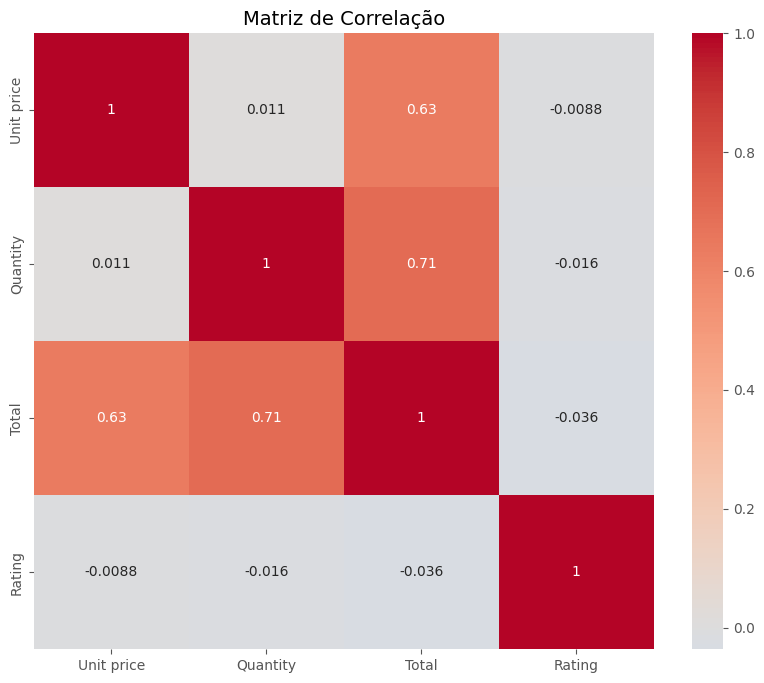

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[['Unit price', 'Quantity', 'Total', 'Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação', fontsize=14)
plt.show()

In [ ]:
#Vendas mensais aqui aparece apenas 3 por conta que no dataset possui apenas esses 3 meses.
monthly_sales = df.groupby('Month')['Total'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('Month')

fig = px.line(monthly_sales, x='Month', y='Total',
              title='Vendas Mensais no Supermercado',
              labels={'Total': 'Total de Vendas (USD)', 'Month': 'Mês'})
fig.show()

In [ ]:
#Principais estatisticas.
print(df[['Unit price', 'Quantity', 'Total', 'Rating']].describe())

        Unit price     Quantity       Total      Rating
count  1000.000000  1000.000000  1000.00000  1000.00000
mean     55.672130     5.510000   307.58738     6.97270
std      26.494628     2.923431   234.17651     1.71858
min      10.080000     1.000000    10.17000     4.00000
25%      32.875000     3.000000   118.49750     5.50000
50%      55.230000     5.000000   241.76000     7.00000
75%      77.935000     8.000000   448.90500     8.50000
max      99.960000    10.000000   993.00000    10.00000


In [ ]:
insights = """
Principais Insights da Análise:

1. Desempenho por Cidade:
   - Yangon foi a cidade com maior volume de vendas.
   - Naypyitaw teve o menor volume, mas com avaliações ligeiramente mais altas.

2. Linhas de Produto:
   - 'Electronic accessories' e 'Food and beverages' foram as categorias mais vendidas.
   - 'Health and beauty' teve o menor volume de vendas.

3. Padrões Temporais:
   - As vendas são mais altas entre 14h e 19h.
   - Fevereiro foi o mês com menor volume de vendas.

4. Comportamento do Cliente:
   - A maioria das avaliações está entre 6 e 9.
   - Existe uma leve correlação positiva entre quantidade comprada e avaliação.
   - Mulheres representam 49.7% das compras e homens 50.3%.

Recomendações:

Para o Supermercado:
- Aumentar promoções em Naypyitaw para impulsionar vendas.
- Expandir o estoque de acessórios eletrônicos que têm alta demanda.
- Oferecer promoções no período da manhã para distribuir melhor o fluxo de clientes.

Para Melhorar Satisfação:
- Investigar os produtos/serviços que recebem avaliações abaixo de 6.
- Treinar equipe para o horário de pico (tarde) manter qualidade do atendimento.
"""

print(insights)


Principais Insights da Análise:

1. Desempenho por Cidade:
   - Yangon foi a cidade com maior volume de vendas.
   - Naypyitaw teve o menor volume, mas com avaliações ligeiramente mais altas.

2. Linhas de Produto:
   - 'Electronic accessories' e 'Food and beverages' foram as categorias mais vendidas.
   - 'Health and beauty' teve o menor volume de vendas.

3. Padrões Temporais:
   - As vendas são mais altas entre 14h e 19h.
   - Fevereiro foi o mês com menor volume de vendas.

4. Comportamento do Cliente:
   - A maioria das avaliações está entre 6 e 9.
   - Existe uma leve correlação positiva entre quantidade comprada e avaliação.
   - Mulheres representam 49.7% das compras e homens 50.3%.

Recomendações:

Para o Supermercado:
- Aumentar promoções em Naypyitaw para impulsionar vendas.
- Expandir o estoque de acessórios eletrônicos que têm alta demanda.
- Oferecer promoções no período da manhã para distribuir melhor o fluxo de clientes.

Para Melhorar Satisfação:
- Investigar os produ

<ipython-input-19-064baa89fadf>:4: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




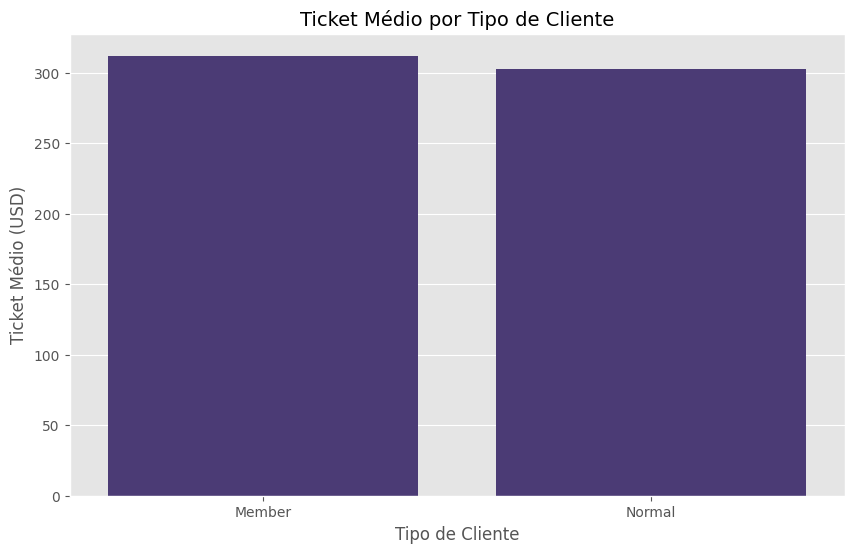

In [ ]:
#Ticket médio de cada cliente

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Customer type', y='Total', estimator=np.mean, ci=None)
plt.title('Ticket Médio por Tipo de Cliente', fontsize=14)
plt.xlabel('Tipo de Cliente')
plt.ylabel('Ticket Médio (USD)')
plt.show()

In [ ]:
#Aqui na variavel X estamos pegando as colunas categoricas para fazer a previsao, ja na y é oq queremos prever no caso o valor total da venda.

X = pd.get_dummies(df.drop(['Invoice ID', 'Date', 'Time', 'Payment', 'Total'], axis=1))
y = df['Total']

In [ ]:
#Separando em 80% para treino e 20% para testes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Aqui estamos criando 100 arvores de decisao, e depois treinando o modelo com os dados do treino
#Aqui o modelo aprende com os dados de treino (X_train) e as respostas corretas (y_train)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#Aqui primeiro O modelo usa o que aprendeu durante o treino para prever os valores de y para os dados que ele nunca viu antes (os dados de teste).
#Depois calcula o quanto o modelo errou por previsao, quanto menor melhor.

preds = model.predict(X_test)
print(f"O MAE é de {mean_absolute_error(y_test, preds)}")

O MAE é de 0.7286320000000185


In [ ]:
#aqui sao os valores de y, oq estamos prevendo o menor é 43.74 e o maior 696.85 ou seja
#um erro medio de 0.73 é bom NESTE MODELO.
print(y_test[:10])

521    499.02
737    587.60
740    389.27
660    128.91
411     43.74
678    589.50
626    121.74
513    696.85
859    428.67
136    131.55
Name: Total, dtype: float64


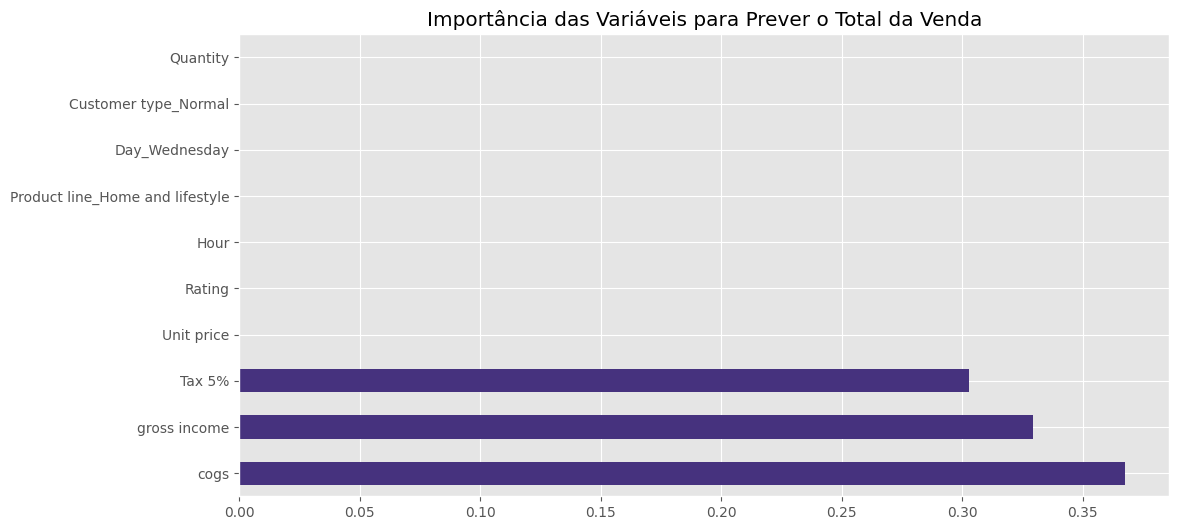

In [ ]:
#Mostra as 10 features que mais influenciam as previsoes, quanto maior a barra mais a variavel
#influencia no valor total de venda.

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Importância das Variáveis para Prever o Total da Venda')
plt.show()

In [ ]:
X = df[["Unit price", "Quantity", "Tax 5%", "gross income"]]
y = df["Total"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"O MAE é de {mae}")

O MAE é de 0.5882610000000137


In [ ]:
print(y_test[:10])

521    499.02
737    587.60
740    389.27
660    128.91
411     43.74
678    589.50
626    121.74
513    696.85
859    428.67
136    131.55
Name: Total, dtype: float64


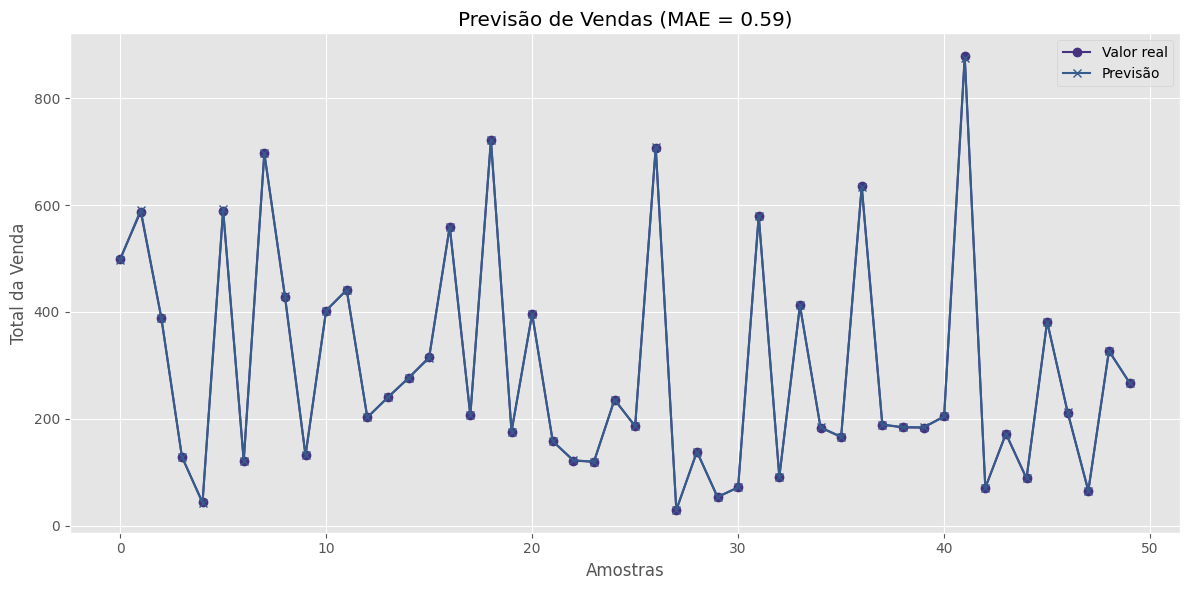

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Valor real', marker='o')
plt.plot(preds[:50], label='Previsão', marker='x')
plt.title(f'Previsão de Vendas (MAE = {mae:.2f})')
plt.xlabel('Amostras')
plt.ylabel('Total da Venda')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Agrupar por dia e somar o total de vendas, junta todas as vendas que aconteceram no mesmo dia e faz o total por dia.
daily_sales = df.groupby('Date')['Total'].sum().reset_index()

In [ ]:
#criar coluna desde o primeiro dia
daily_sales["Days_Since"] = (daily_sales["Date"] - daily_sales["Date"].min()).dt.days

In [ ]:
#Treinando o modelo
X = daily_sales[["Days_Since"]]
y = daily_sales["Total"]
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#Adiciona na coluna prediciton criado no dataframe daily sales o valores que o modelo previu.
daily_sales["Prediction"] = model.predict(X)

In [ ]:
#Primeiro ele pega quantos dias se passaram da primeira ate a ultima data
#depois cria uma lista com os proximos 30 dias
#depois gera uma sequência de datas começando em 2021-03-31, e com 30 dias seguidos.
#criamos o dataframe future_days_df com o mesmo nome e coluna de days_since pois treinamos o modelo com ele
#se nao fizer isso vai funcionar mas com aviso
#apos isso ele faz as previsoes.

last_day = daily_sales["Days_Since"].max()
future_days = np.array(range(last_day + 1, last_day + 31)).reshape(-1, 1)
future_dates = pd.date_range(start=daily_sales["Date"].max() + pd.Timedelta(days=1), periods=30)
future_days_df = pd.DataFrame(future_days, columns=["Days_Since"])
future_prevs = model.predict(future_days_df)

In [ ]:
#Criando dataframe pra colocar os resultados futuros.
future_df = pd.DataFrame({
    "Date": future_dates,
    "Prediction": future_prevs
})


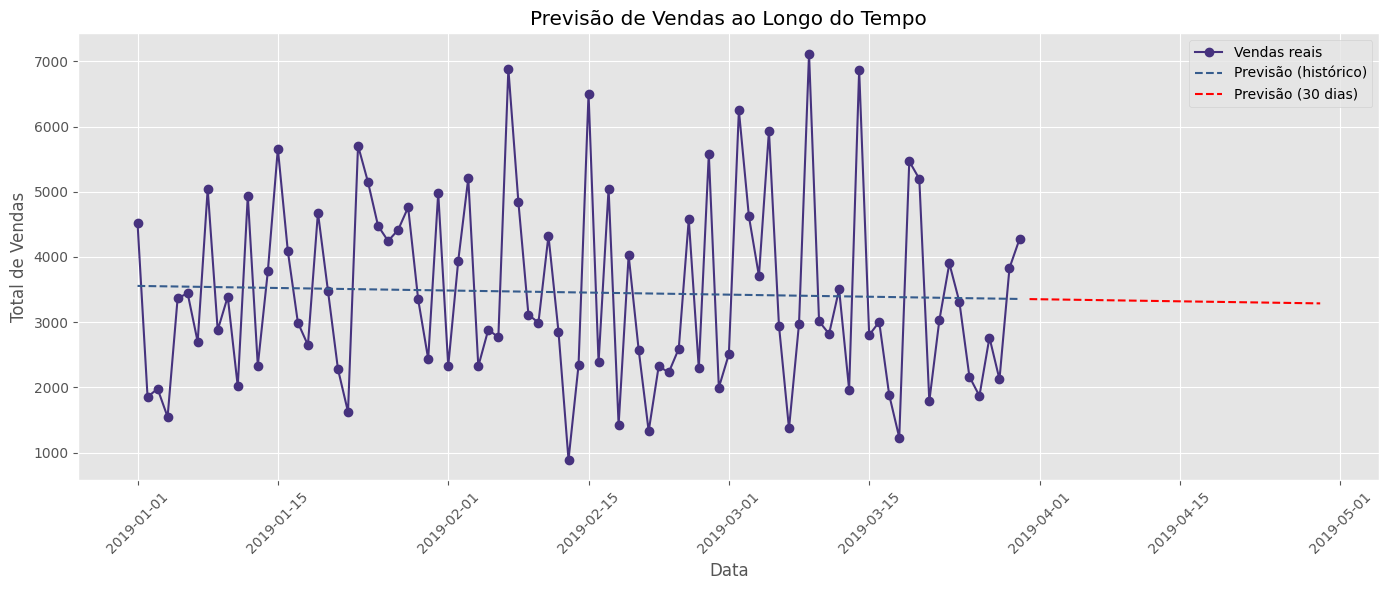

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(daily_sales["Date"], daily_sales["Total"], label="Vendas reais", marker='o')
plt.plot(daily_sales["Date"], daily_sales["Prediction"], label="Previsão (histórico)", linestyle="--")
plt.plot(future_df["Date"], future_df["Prediction"], label="Previsão (30 dias)", linestyle="--", color="red")
plt.xlabel("Data")
plt.ylabel("Total de Vendas")
plt.title("Previsão de Vendas ao Longo do Tempo")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()